In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
FRED_API_KEY = os.getenv('FRED_API_KEY')
if not FRED_API_KEY:
    raise RuntimeError('FRED_API_KEY is not set. Copy .env.example to .env')
import pandas as pd
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
fred = Fred(api_key=FRED_API_KEY)
start_date = '1950-07-01'
end_date = '2025-11-06'

In [2]:
ticker = ['QQQ','XLP','XLY','GC=F','BTC-USD']
stock = yf.download(ticker, start=start_date, end=end_date)['Close']
stock = stock.ffill().resample("MS").first()
ticker = 'CSUSHPINSA'
home = fred.get_series(ticker, start_date, end_date)
home.name = "Home"
stock

C:\Users\USER\AppData\Local\Temp\ipykernel_30452\3361798354.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed


Ticker,BTC-USD,GC=F,QQQ,XLP,XLY
Date,,,,,
1998-12-01,NaN,NaN,NaN,14.177588,18.833813
1999-01-01,NaN,NaN,NaN,14.411653,19.203537
1999-02-01,NaN,NaN,NaN,14.277907,20.359003
1999-03-01,NaN,NaN,43.184212,14.119072,20.197243
1999-04-01,NaN,NaN,45.298531,14.194254,21.144531
...,...,...,...,...,...
2025-07-01,105698.281250,3336.699951,546.356628,81.421288,217.875717
2025-08-01,113320.085938,3347.699951,553.238647,79.613686,215.709534
2025-09-01,109250.593750,3473.699951,569.739563,80.229454,231.331985


In [3]:
df = stock.join(home,how='left')
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)
df

,BTC-USD,GC=F,QQQ,XLP,XLY,Home
Date,,,,,,
2014-09-01,457.334015,1263.699951,91.699875,33.495838,60.693783,167.228
2014-10-01,383.614990,1214.599976,89.291008,33.469090,58.114723,166.897
2014-11-01,325.748993,1171.099976,93.139679,34.872654,60.146080,166.645
2014-12-01,379.244995,1218.000000,96.271873,36.567387,62.725040,166.446
2015-01-01,314.248993,1183.900024,95.192352,36.461906,63.987247,166.233
...,...,...,...,...,...,...
2025-05-01,96492.335938,3210.000000,480.582489,80.018227,197.580688,331.450
2025-06-01,105652.101562,3288.899902,517.927246,81.705002,212.970764,331.671
2025-07-01,105698.281250,3336.699951,546.356628,81.421288,217.875717,330.978


In [4]:
df['QQQ'] = df['QQQ'].pct_change()
df['XLY'] = df['XLY'].pct_change()
df['XLP'] = df['XLP'].pct_change()
df['GC=F'] = df['GC=F'].pct_change()
df['BTC-USD'] = df['BTC-USD'].pct_change()
df['Home'] = df['Home'].pct_change()

In [5]:
df.rename(columns={'QQQ':'기술주'},inplace=True)
df.rename(columns={'XLY':'경기민감주'},inplace=True)
df.rename(columns={'XLP':'경기방어주'},inplace=True)
df.rename(columns={'GC=F':'금'},inplace=True)
df.rename(columns={'BTC-USD':'비트코인'},inplace=True)
df.rename(columns={'Home':'부동산'},inplace=True)

In [6]:
indicator = pd.read_csv("../data/indicator.csv")
indicator['Date']=pd.to_datetime(indicator['Date'])

In [7]:
indicator.rename(columns={'rate':'금리'},inplace=True)
indicator.rename(columns={'government':'미국채'},inplace=True)
indicator.rename(columns={'dolar':'달러인덱스'},inplace=True)
indicator.rename(columns={'cpi':'CPI'},inplace=True)
indicator.rename(columns={'gdp':'GDP'},inplace=True)
indicator.rename(columns={'oil':'유가'},inplace=True)
indicator.rename(columns={'hire':'고용률'},inplace=True)
indicator.rename(columns={'fear':'공포지수'},inplace=True)
indicator.rename(columns={'fire':'실업률'},inplace=True)
indicator.rename(columns={'msupply':'통화량'},inplace=True)

In [8]:
corr_df = df.merge(indicator,on='Date', how = 'inner')
corr_df

,Date,비트코인,금,기술주,경기방어주,경기민감주,부동산,금리,미국채,달러인덱스,CPI,GDP,유가,고용률,공포지수,실업률,통화량
0,2014-09-01,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-0.10,0.020067,0.000072,0.000000,-0.050480,0.002111,-4.78,-0.2,0.003595
1,2014-10-01,-0.161193,-0.038854,-0.026269,-0.000799,-0.042493,-0.001979,0.00,0.00,0.036935,-0.000198,0.000000,-0.023461,0.001677,4.46,-0.2,0.006416
2,2014-11-01,-0.150844,-0.035814,0.043103,0.041936,0.034954,-0.001510,0.00,-0.06,0.015463,-0.001883,0.000000,-0.131915,0.002096,-1.98,0.1,0.003516
3,2014-12-01,0.164225,0.040048,0.033629,0.048598,0.042878,-0.001194,0.03,-0.14,0.006578,-0.003085,0.000000,-0.124286,0.001956,-0.44,-0.2,0.007205
4,2015-01-01,-0.171383,-0.027997,-0.011213,-0.002885,0.020123,-0.001280,-0.01,-0.10,0.038656,-0.006370,0.780554,-0.235720,0.001453,3.50,0.1,0.007418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,2025-05-01,0.132949,0.029209,0.018997,-0.008192,-0.005864,0.004671,0.00,0.08,-0.037470,0.000809,0.000000,-0.153889,0.000119,2.83,0.0,0.002614
129,2025-06-01,0.094927,0.024579,0.077707,0.021080,0.077893,0.000667,0.00,0.21,-0.014182,0.002870,0.000000,0.044232,-0.000082,-6.24,-0.1,0.005269
130,2025-07-01,0.000437,0.014534,0.054891,-0.003472,0.023031,-0.002089,0.00,-0.20,-0.021980,0.001966,0.000000,0.053264,0.000452,-1.53,0.1,0.003938
131,2025-08-01,0.072109,0.003297,0.012596,-0.022201,-0.009942,-0.003493,0.00,-0.03,0.025532,0.003825,0.000000,0.026261,-0.000025,3.55,0.1,0.003613


In [13]:
corr_df.to_csv("../data/Assets+indicator.csv",index=False)

In [11]:
assets= ['기술주','경기방어주','경기민감주','금','부동산','비트코인']
indicators= ['금리','미국채','달러인덱스','CPI','GDP','유가','고용률','공포지수','실업률','통화량']
corr_matrix = corr_df[indicators+assets].corr()
corr_indi_assets = corr_matrix.loc[indicators, assets]
corr_indi_assets

,기술주,경기방어주,경기민감주,금,부동산,비트코인
금리,0.011659,0.155820,0.045419,-0.087858,-0.153003,-0.016150
미국채,-0.103975,-0.150571,-0.046914,-0.406960,0.119701,-0.024551
달러인덱스,-0.336591,-0.312068,-0.285264,-0.456936,0.010514,-0.123099
CPI,0.076760,0.052470,0.094483,-0.003043,0.355046,0.024109
GDP,-0.158770,-0.123913,-0.175646,-0.069428,-0.057429,-0.031636
유가,0.270373,0.154672,0.304638,0.010459,0.237392,0.099370
고용률,0.263925,0.223838,0.364605,0.028611,-0.002133,0.127981
공포지수,-0.661217,-0.579633,-0.677373,0.007691,0.019225,-0.206911
실업률,-0.269861,-0.244277,-0.376655,-0.052316,-0.002959,-0.164967
통화량,-0.004251,-0.055195,-0.032964,0.055912,0.182212,0.031100


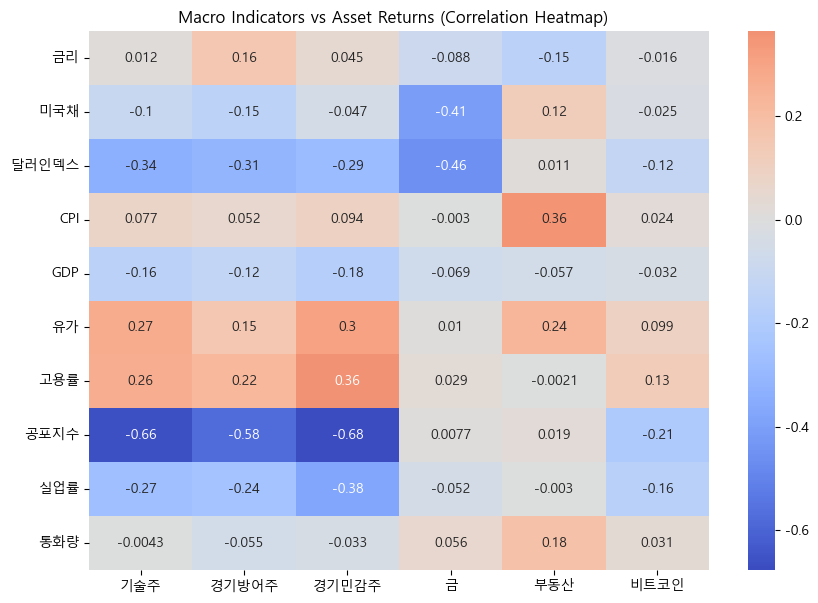

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(corr_indi_assets, annot=True, cmap='coolwarm', center=0)
plt.title("Macro Indicators vs Asset Returns (Correlation Heatmap)  ")
plt.show()